<a href="https://colab.research.google.com/github/aendris18/Frist-class/blob/main/multiclass%20hbmd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
# CELL 1: Environment Setup and Imports
# =============================================================================
# Install required packages (run once)
# !pip install pandas numpy scikit-learn tensorflow matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: []


In [15]:
# =============================================================================
# CELL 2: Data Loading
# =============================================================================
# Download UNSW-NB15 from: https://research.unsw.edu.au/projects/unsw-nb15-dataset
# You need these files:
# - UNSW_NB15_training-set.csv
# - UNSW_NB15_testing-set.csv

# Load the pre-split datasets (recommended for best results)
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")

Training set shape: (62844, 45)
Testing set shape: (56797, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [16]:
# =============================================================================
# CELL 2: DATA LOADING - GOOGLE COLAB
# =============================================================================

import pandas as pd
import os

train_file = "/content/UNSW_NB15_training-set.csv"
test_file = "/content/UNSW_NB15_testing-set.csv"

print("Training file exists:", os.path.isfile(train_file))
print("Testing file exists:", os.path.isfile(test_file))

# Load datasets
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("\nTraining set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nFirst 5 training records:")
display(train_df.head())

print("\nFirst 5 testing records:")
display(test_df.head())

Training file exists: True
Testing file exists: True

Training set shape: (82332, 45)
Testing set shape: (175341, 45)

Training columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

First 5 training records:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0



First 5 testing records:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


Training Set - Attack Category Distribution:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

Class imbalance ratio: 840.9x


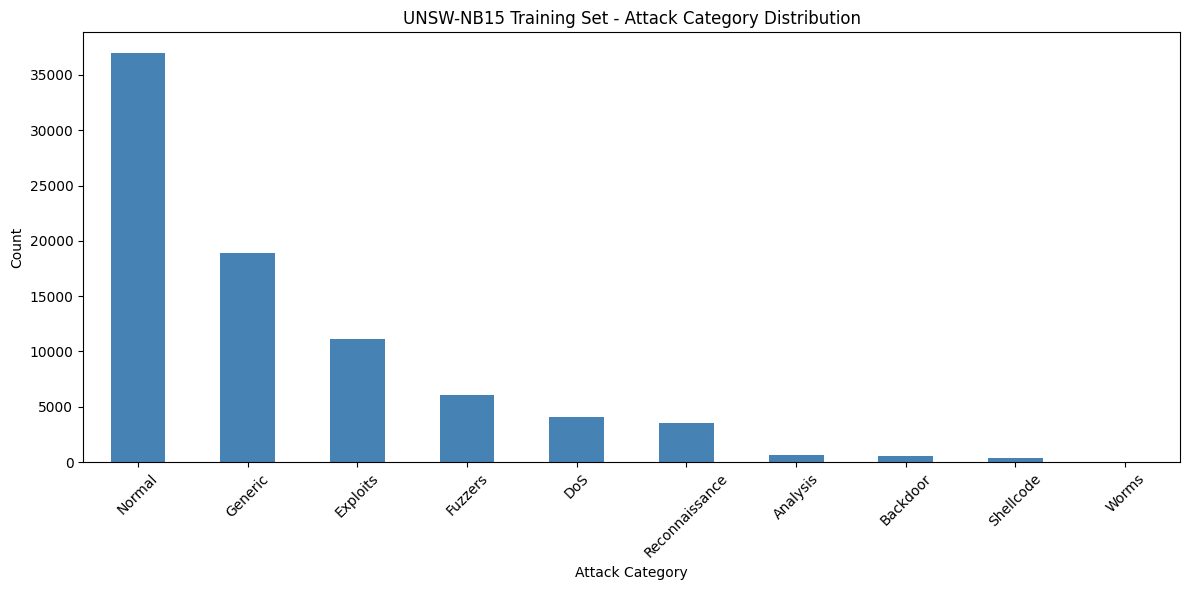

In [17]:
# =============================================================================
# CELL 3: Exploratory Data Analysis
# =============================================================================
# Check class distribution
print("Training Set - Attack Category Distribution:")
print(train_df['attack_cat'].value_counts())
print(f"\nClass imbalance ratio: {train_df['attack_cat'].value_counts().max() / train_df['attack_cat'].value_counts().min():.1f}x")

# Visualize class distribution
plt.figure(figsize=(12, 6))
train_df['attack_cat'].value_counts().plot(kind='bar', color='steelblue')
plt.title('UNSW-NB15 Training Set - Attack Category Distribution')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# =============================================================================
# CELL 4: Data Preprocessing
# =============================================================================
# Identify categorical and numerical columns
categorical_cols = ['proto', 'service', 'state']
numerical_cols = [col for col in train_df.columns if col not in categorical_cols + ['attack_cat', 'label', 'id']]

print(f"Categorical features: {categorical_cols}")
print(f"Numerical features: {len(numerical_cols)} features")

# Handle missing values (if any)
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

# One-hot encode categorical features
train_encoded = pd.get_dummies(train_df, columns=categorical_cols, drop_first=False)
test_encoded = pd.get_dummies(test_df, columns=categorical_cols, drop_first=False)

# Align columns (ensure test has same features as train)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# Separate features and labels
X_train = train_encoded.drop(['attack_cat', 'label', 'id'], axis=1, errors='ignore')
y_train = train_encoded['attack_cat']

X_test = test_encoded.drop(['attack_cat', 'label', 'id'], axis=1, errors='ignore')
y_test = test_encoded['attack_cat']

print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features after encoding: {X_train.shape[1]}")

Categorical features: ['proto', 'service', 'state']
Numerical features: 39 features
Feature matrix shape: (82332, 190)
Number of features after encoding: 190


In [19]:
# =============================================================================
# CELL 5: Feature Scaling and Label Encoding
# =============================================================================
# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Label encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to one-hot encoding for categorical crossentropy
num_classes = len(label_encoder.classes_)
y_train_categorical = to_categorical(y_train_encoded, num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes)

print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

# Reshape for CNN-LSTM (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped training data: {X_train_reshaped.shape}")
print(f"Reshaped testing data: {X_test_reshaped.shape}")

Number of classes: 10
Classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
Reshaped training data: (82332, 190, 1)
Reshaped testing data: (175341, 190, 1)


In [20]:
# =============================================================================
# CELL 6: Class Weight Computation (Critical for Imbalance)
# =============================================================================
# Compute class weights to handle severe imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights (higher = more important for rare classes):")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name}: {class_weight_dict[i]:.2f}")

Class Weights (higher = more important for rare classes):
  Analysis: 12.16
  Backdoor: 14.12
  DoS: 2.01
  Exploits: 0.74
  Fuzzers: 1.36
  Generic: 0.44
  Normal: 0.22
  Reconnaissance: 2.36
  Shellcode: 21.78
  Worms: 187.12


In [21]:
# =============================================================================
# CELL 7: Hybrid CNN-LSTM Model Architecture
# =============================================================================
# This architecture is optimized for UNSW-NB15 based on research showing
# CNN-LSTM outperforms standalone CNN or LSTM models [citation:2][citation:5]

def build_cnn_lstm_model(input_shape, num_classes):
    model = Sequential([
        # CNN Block 1: Extract local spatial features
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # CNN Block 2: Deeper feature extraction
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # CNN Block 3
        Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(0.3),

        # LSTM Block: Capture temporal dependencies
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        # Dense Classification Head
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    return model

# Build the model
model = build_cnn_lstm_model((X_train_reshaped.shape[1], 1), num_classes)

# Compile with categorical crossentropy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 190, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 190, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 95, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 95, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 95, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 95, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 47, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 47, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 47, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 47, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,578 (1.49 MB)

 Trainable params: 388,426 (1.48 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [24]:
# =============================================================================
# CELL 8: Model Training with Callbacks
# =============================================================================
# Callbacks for optimal training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_cnn_lstm_ids.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
history = model.fit(
    X_train_reshaped, y_train_categorical,
    validation_split=0.15,  # 15% for validation
    epochs=20,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
184/274 ━━━━━━━━━━━━━━━━━━━━ 1:26 965ms/step - accuracy: 0.4212 - loss: 1.6971 - precision: 0.8006 - recall: 0.3601

KeyboardInterrupt: 

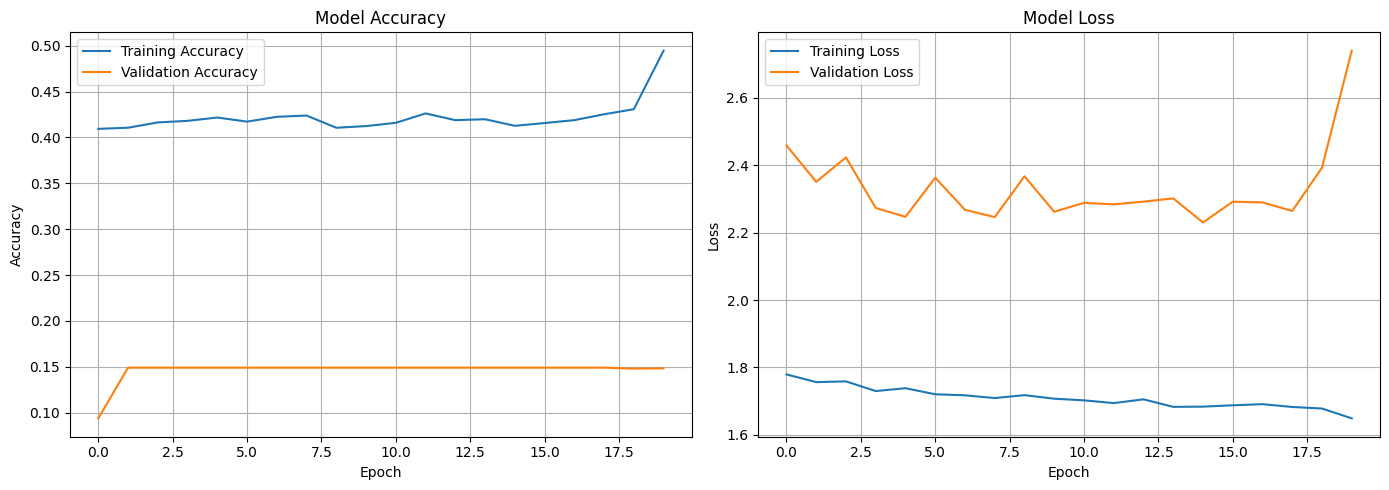

In [25]:
# =============================================================================
# CELL 9: Training History Visualization
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [26]:
# =============================================================================
# CELL 10: Model Evaluation on Test Set
# =============================================================================
# Load best model
model.load_weights('best_cnn_lstm_ids.h5')

# Predict on test set
y_pred_probs = model.predict(X_test_reshaped, batch_size=256)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_encoded

# Calculate metrics
test_accuracy = accuracy_score(y_true, y_pred)
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
macro_f1 = f1_score(y_true, y_pred, average='macro')

print("="*60)
print("FINAL TEST RESULTS - CNN-LSTM HYBRID MODEL")
print("="*60)
print(f"Overall Accuracy:     {test_accuracy*100:.2f}%")
print(f"Weighted F1-Score:    {weighted_f1:.4f}")
print(f"Macro F1-Score:       {macro_f1:.4f}")
print("="*60)

# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4))

685/685 ━━━━━━━━━━━━━━━━━━━━ 171s 248ms/step
FINAL TEST RESULTS - CNN-LSTM HYBRID MODEL
Overall Accuracy:     40.99%
Weighted F1-Score:    0.4362
Macro F1-Score:       0.2173

DETAILED CLASSIFICATION REPORT:
                precision    recall  f1-score   support

      Analysis     0.0000    0.0000    0.0000      2000
      Backdoor     0.0451    0.8282    0.0855      1746
           DoS     0.0000    0.0000    0.0000     12264
      Exploits     0.4804    0.2185    0.3003     33393
       Fuzzers     0.2351    0.5712    0.3331     18184
       Generic     0.9863    0.9779    0.9821     40000
        Normal     0.9638    0.2310    0.3726     56000
Reconnaissance     0.0000    0.0000    0.0000     10491
     Shellcode     0.0478    0.5084    0.0874      1133
         Worms     0.0061    0.8769    0.0121       130

      accuracy                         0.4099    175341
     macro avg     0.2765    0.4212    0.2173    175341
  weighted avg     0.6495    0.4099    0.4362    175341



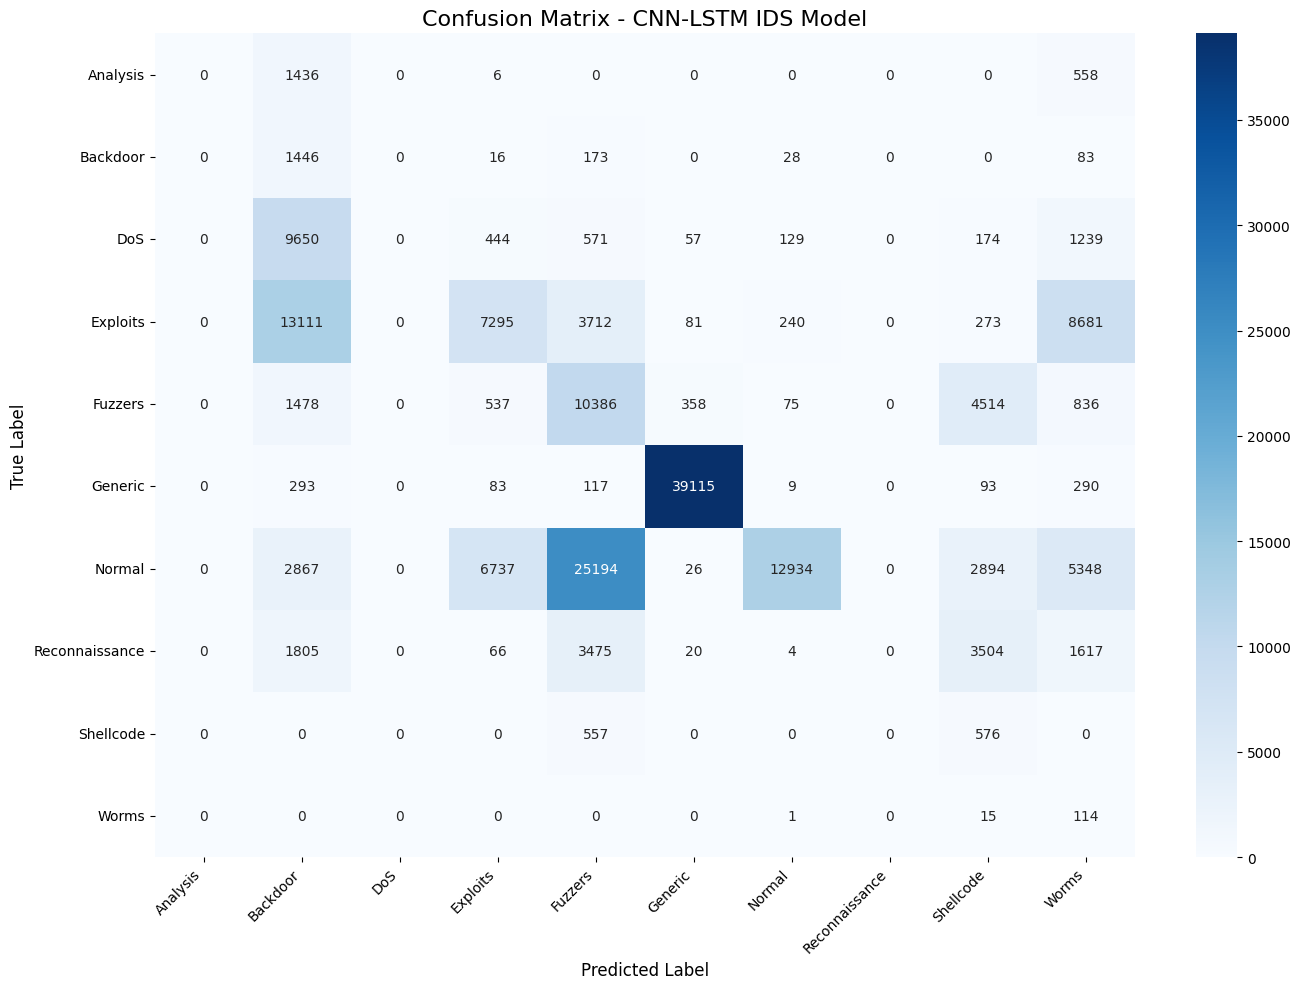

In [27]:
# =============================================================================
# CELL 11: Confusion Matrix Visualization
# =============================================================================
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - CNN-LSTM IDS Model', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# =============================================================================
# CELL 12: Save Model and Artifacts for Deployment
# =============================================================================
import joblib

# Save the model
model.save('unsw_nb15_cnn_lstm_model.h5')

# Save preprocessing artifacts
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

# Save feature column names for inference alignment
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print("Model and artifacts saved successfully!")
print("\nFiles created:")
print("  - unsw_nb15_cnn_lstm_model.h5 (trained model)")
print("  - scaler.pkl (feature scaler)")
print("  - label_encoder.pkl (class label encoder)")
print("  - feature_columns.pkl (feature names for alignment)")

Model and artifacts saved successfully!

Files created:
  - unsw_nb15_cnn_lstm_model.h5 (trained model)
  - scaler.pkl (feature scaler)
  - label_encoder.pkl (class label encoder)
  - feature_columns.pkl (feature names for alignment)
